# Day 9: Knockout Match Predictions

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import json

from pathlib import Path

## Loading data

In [2]:
def find_project_root():
    current = Path.cwd()

    for path in [current] + list(current.parents):
        if (path / "data").exists() and (path / "models").exists():
            return path

    raise FileNotFoundError(
        "Could not find project root. Make sure this notebook is inside the project folder."
    )


PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", DATA_PROCESSED)
print("Models folder:", MODELS_DIR)

Project root: /Users/rayhanrinzan/fifa-world-cup-predictor
Processed data folder: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed
Models folder: /Users/rayhanrinzan/fifa-world-cup-predictor/models


## Loading model and metadata

In [3]:
model_path = MODELS_DIR / "current_best_model_with_elo.pkl"
metadata_path = MODELS_DIR / "current_best_model_with_elo_metadata.json"

model = joblib.load(model_path)

with open(metadata_path, "r") as f:
    metadata = json.load(f)

features = metadata["features"]

print("Loaded model:", metadata["model_name"])
print("Features used by model:")
features

Loaded model: gradient_boosting_balanced_clean_elo
Features used by model:


['last_5_points_per_match_diff',
 'last_5_goals_for_per_match_diff',
 'last_5_goals_against_per_match_diff',
 'last_5_goal_difference_per_match_diff',
 'last_5_win_diff',
 'last_5_draw_diff',
 'last_5_loss_diff',
 'elo_diff']

## Load team form and elo data

In [4]:
team_matches = pd.read_csv(DATA_PROCESSED / "team_matches.csv")
final_elo_df = pd.read_csv(DATA_PROCESSED / "final_elo_ratings.csv")

team_matches["date"] = pd.to_datetime(team_matches["date"])

team_matches_played = team_matches.dropna(
    subset=["goals_for", "goals_against"]
).copy()

team_matches_played = team_matches_played.sort_values(["team", "date"])

final_elo_map = dict(zip(final_elo_df["team"], final_elo_df["final_elo"]))

print("Team matches:", team_matches_played.shape)
print("Teams with Elo ratings:", len(final_elo_map))

team_matches_played.head()

Team matches: (98756, 13)
Teams with Elo ratings: 336


,date,team,opponent,goals_for,goals_against,tournament,city,country,neutral,is_home,result,points,goal_difference
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,Friendly,Sukhumi,Georgia,False,True,draw,1,0.0
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,Friendly,Stepanakert,Azerbaijan,False,False,loss,0,-3.0
2,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,Friendly,Sukhumi,Georgia,False,True,win,3,3.0
3,2014-06-01,Abkhazia,Occitania,1.0,1.0,CONIFA World Football Cup,Östersund,Sweden,True,True,draw,1,0.0
4,2014-06-02,Abkhazia,Sápmi,2.0,1.0,CONIFA World Football Cup,Östersund,Sweden,False,False,win,3,1.0


In [5]:
all_teams = sorted(
    set(team_matches_played["team"].dropna()) | set(final_elo_df["team"].dropna())
)

team_lookup = {team.lower(): team for team in all_teams}


def resolve_team_name(team_name):
    """
    Resolves team names while allowing different capitalization.

    Example:
    'france' -> 'France'
    """

    if team_name in all_teams:
        return team_name

    team_name_lower = team_name.lower()

    if team_name_lower in team_lookup:
        return team_lookup[team_name_lower]

    possible_matches = [
        team for team in all_teams
        if team_name_lower in team.lower()
    ]

    if len(possible_matches) > 0:
        raise ValueError(
            f"Team '{team_name}' was not found exactly. Did you mean one of these? {possible_matches[:10]}"
        )

    raise ValueError(f"Team '{team_name}' was not found in the dataset.")

## Create team form, build match feature, and prediction functions

In [6]:
def get_current_team_form(team_name, n=5):
    """
    Gets a team's most recent form from its last n played matches.
    """

    team_name = resolve_team_name(team_name)

    team_history = (
        team_matches_played[team_matches_played["team"] == team_name]
        .sort_values("date")
        .tail(n)
    )

    matches_used = len(team_history)

    if matches_used == 0:
        return {
            "last_5_points_per_match": 0,
            "last_5_goals_for_per_match": 0,
            "last_5_goals_against_per_match": 0,
            "last_5_goal_difference_per_match": 0,
            "last_5_win": 0,
            "last_5_draw": 0,
            "last_5_loss": 0,
            "matches_used": 0
        }

    return {
        "last_5_points_per_match": team_history["points"].sum() / matches_used,
        "last_5_goals_for_per_match": team_history["goals_for"].sum() / matches_used,
        "last_5_goals_against_per_match": team_history["goals_against"].sum() / matches_used,
        "last_5_goal_difference_per_match": team_history["goal_difference"].sum() / matches_used,
        "last_5_win": (team_history["result"] == "win").sum(),
        "last_5_draw": (team_history["result"] == "draw").sum(),
        "last_5_loss": (team_history["result"] == "loss").sum(),
        "matches_used": matches_used
    }

In [7]:
form_features = [
    "last_5_points_per_match",
    "last_5_goals_for_per_match",
    "last_5_goals_against_per_match",
    "last_5_goal_difference_per_match",
    "last_5_win",
    "last_5_draw",
    "last_5_loss"
]


def build_match_features(team_a, team_b):
    """
    Builds one feature row for Team A vs Team B using the same feature columns
    that the saved model expects.
    """

    team_a = resolve_team_name(team_a)
    team_b = resolve_team_name(team_b)

    team_a_form = get_current_team_form(team_a)
    team_b_form = get_current_team_form(team_b)

    row = {}

    for feature in form_features:
        diff_col = f"{feature}_diff"
        row[diff_col] = team_a_form[feature] - team_b_form[feature]

    team_a_elo = final_elo_map.get(team_a, 1500)
    team_b_elo = final_elo_map.get(team_b, 1500)

    row["elo_diff"] = team_a_elo - team_b_elo

    # Make sure every model feature exists.
    # Any missing expected feature gets neutral value 0.
    for feature in features:
        if feature not in row:
            row[feature] = 0

    X_match = pd.DataFrame([row])[features]

    return X_match

In [8]:
def predict_match(team_a, team_b):
    """
    Predicts a normal match outcome from Team A's perspective.
    """

    team_a = resolve_team_name(team_a)
    team_b = resolve_team_name(team_b)

    X_match = build_match_features(team_a, team_b)

    predicted_label = model.predict(X_match)[0]
    probabilities = model.predict_proba(X_match)[0]

    probability_map = dict(zip(model.classes_, probabilities))

    team_a_win_prob = probability_map.get("win", 0)
    draw_prob = probability_map.get("draw", 0)
    team_b_win_prob = probability_map.get("loss", 0)

    result = pd.DataFrame([
        {
            "team_a": team_a,
            "team_b": team_b,
            "predicted_outcome_from_team_a_perspective": predicted_label,
            "team_a_win_probability": team_a_win_prob,
            "draw_probability": draw_prob,
            "team_b_win_probability": team_b_win_prob,
        }
    ])

    return result

## Create function to predict knockouts

In [9]:
def predict_knockout_match(team_a, team_b):
    """
    Predicts which team advances in a knockout match.

    Beginner assumption:
    If the match is a draw after normal time, both teams get half of the draw probability.
    """

    prediction = predict_match(team_a, team_b)

    team_a = prediction.loc[0, "team_a"]
    team_b = prediction.loc[0, "team_b"]

    team_a_win_prob = prediction.loc[0, "team_a_win_probability"]
    draw_prob = prediction.loc[0, "draw_probability"]
    team_b_win_prob = prediction.loc[0, "team_b_win_probability"]

    team_a_adv_prob = team_a_win_prob + 0.5 * draw_prob
    team_b_adv_prob = team_b_win_prob + 0.5 * draw_prob

    predicted_advancing_team = (
        team_a if team_a_adv_prob >= team_b_adv_prob else team_b
    )

    prediction["team_a_advancement_probability"] = team_a_adv_prob
    prediction["team_b_advancement_probability"] = team_b_adv_prob
    prediction["predicted_advancing_team"] = predicted_advancing_team

    return prediction

In [10]:
def display_knockout_prediction(team_a, team_b):
    prediction = predict_knockout_match(team_a, team_b)

    row = prediction.iloc[0]

    print(f"{row['team_a']} vs {row['team_b']}")
    print("-" * 50)
    print(f"{row['team_a']} win probability: {row['team_a_win_probability']:.3f}")
    print(f"Draw probability: {row['draw_probability']:.3f}")
    print(f"{row['team_b']} win probability: {row['team_b_win_probability']:.3f}")
    print()
    print(f"{row['team_a']} advancement probability: {row['team_a_advancement_probability']:.3f}")
    print(f"{row['team_b']} advancement probability: {row['team_b_advancement_probability']:.3f}")
    print()
    print(f"Predicted advancing team: {row['predicted_advancing_team']}")

    return prediction

In [11]:
display_knockout_prediction("France", "Brazil")

France vs Brazil
--------------------------------------------------
France win probability: 0.336
Draw probability: 0.395
Brazil win probability: 0.269

France advancement probability: 0.533
Brazil advancement probability: 0.467

Predicted advancing team: France


,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability,team_b_advancement_probability,predicted_advancing_team
0,France,Brazil,draw,0.336211,0.394566,0.269223,0.533494,0.466506,France


## Running some tests

In [12]:
test_matchups = [
    ("France", "Brazil"),
    ("Argentina", "Germany"),
    ("England", "Spain"),
    ("Portugal", "Netherlands"),
    ("United States", "Mexico"),
    ("Japan", "South Korea")
]

knockout_predictions = []

for team_a, team_b in test_matchups:
    prediction = predict_knockout_match(team_a, team_b)
    knockout_predictions.append(prediction)

knockout_predictions_df = pd.concat(knockout_predictions, ignore_index=True)

knockout_predictions_df

,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability,team_b_advancement_probability,predicted_advancing_team
0,France,Brazil,draw,0.336211,0.394566,0.269223,0.533494,0.466506,France
1,Argentina,Germany,win,0.445704,0.382240,0.172056,0.636824,0.363176,Argentina
2,England,Spain,loss,0.212127,0.386437,0.401436,0.405346,0.594654,Spain
3,Portugal,Netherlands,win,0.378319,0.374693,0.246989,0.565665,0.434335,Portugal
4,United States,Mexico,loss,0.278302,0.328289,0.393409,0.442447,0.557553,Mexico
5,Japan,South Korea,win,0.437537,0.376273,0.186190,0.625673,0.374327,Japan


In [13]:
knockout_predictions_df["max_advancement_probability"] = knockout_predictions_df[
    [
        "team_a_advancement_probability",
        "team_b_advancement_probability"
    ]
].max(axis=1)

knockout_predictions_df.sort_values(
    "max_advancement_probability",
    ascending=False
)

,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability,team_b_advancement_probability,predicted_advancing_team,max_advancement_probability
1,Argentina,Germany,win,0.445704,0.382240,0.172056,0.636824,0.363176,Argentina,0.636824
5,Japan,South Korea,win,0.437537,0.376273,0.186190,0.625673,0.374327,Japan,0.625673
2,England,Spain,loss,0.212127,0.386437,0.401436,0.405346,0.594654,Spain,0.594654
3,Portugal,Netherlands,win,0.378319,0.374693,0.246989,0.565665,0.434335,Portugal,0.565665
4,United States,Mexico,loss,0.278302,0.328289,0.393409,0.442447,0.557553,Mexico,0.557553
0,France,Brazil,draw,0.336211,0.394566,0.269223,0.533494,0.466506,France,0.533494


## Creating functions for each round of knockouts

In [14]:
def simulate_round(matchups, round_name):
    """
    Simulates one knockout round.

    Parameters:
    - matchups: list of tuples, where each tuple is (team_a, team_b)
    - round_name: name of the round, like "Round of 16"

    Returns:
    - winners: list of teams that advanced
    - round_results_df: DataFrame with prediction details for each match
    """

    winners = []
    round_results = []

    for match_number, (team_a, team_b) in enumerate(matchups, start=1):
        prediction = predict_knockout_match(team_a, team_b)
        row = prediction.iloc[0].to_dict()

        winner = row["predicted_advancing_team"]
        winners.append(winner)

        row["round"] = round_name
        row["match_number"] = match_number

        round_results.append(row)

    round_results_df = pd.DataFrame(round_results)

    return winners, round_results_df

## Creating next round of matchups

In [15]:
def make_next_round_matchups(winners):
    """
    Creates the next round's matchups by pairing winners in order.

    Example:
    [A, B, C, D] -> [(A, B), (C, D)]
    """

    if len(winners) % 2 != 0:
        raise ValueError("Number of winners must be even to create the next round.")

    next_round_matchups = []

    for i in range(0, len(winners), 2):
        next_round_matchups.append((winners[i], winners[i + 1]))

    return next_round_matchups

## Simulating 2026 FIFA World Cup Knockout Stage

In [16]:
def simulate_knockout_bracket(round_of_32_matchups):
    """
    Simulates a full deterministic knockout bracket:
    Round of 32 -> Round of 16 -> Quarterfinals -> Semifinals -> Final -> Champion
    """

    all_round_results = []

    # Round of 16
    r32_winners, r32_results = simulate_round(
        round_of_32_matchups,
        "Round of 32"
    )
    all_round_results.append(r32_results)
    
    # Round of 16
    round_of_16_matchups = make_next_round_matchups(r32_winners)
    
    r16_winners, r16_results = simulate_round(
        round_of_16_matchups,
        "Round of 16"
    )
    all_round_results.append(r16_results)

    # Quarterfinals
    quarterfinal_matchups = make_next_round_matchups(r16_winners)

    qf_winners, qf_results = simulate_round(
        quarterfinal_matchups,
        "Quarterfinals"
    )
    all_round_results.append(qf_results)

    # Semifinals
    semifinal_matchups = make_next_round_matchups(qf_winners)

    sf_winners, sf_results = simulate_round(
        semifinal_matchups,
        "Semifinals"
    )
    all_round_results.append(sf_results)

    # Final
    final_matchup = make_next_round_matchups(sf_winners)

    final_winner, final_results = simulate_round(
        final_matchup,
        "Final"
    )
    all_round_results.append(final_results)

    champion = final_winner[0]

    bracket_results_df = pd.concat(all_round_results, ignore_index=True)

    return champion, bracket_results_df

In [17]:
round_of_32 = [
    ("Germany", "Paraguay"),
    ("France", "Sweden"),
    ("South Africa", "Canada"),
    ("Netherlands", "Morocco"),

    ("Portugal", "Croatia"),
    ("Spain", "Austria"),
    ("United States", "Bosnia and Herzegovina"),
    ("Belgium", "Senegal"),

    ("Brazil", "Japan"),
    ("Ivory Coast", "Norway"),
    ("Mexico", "Ecuador"),
    ("England", "DR Congo"),

    ("Argentina", "Cape Verde"),
    ("Australia", "Egypt"),
    ("Switzerland", "Algeria"),
    ("Colombia", "Ghana")
]

## Displaying results

In [18]:
champion, bracket_results_df = simulate_knockout_bracket(round_of_32)

print("Predicted Champion:", champion)

bracket_results_df

Predicted Champion: Spain


,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability,team_b_advancement_probability,predicted_advancing_team,round,match_number
0,Germany,Paraguay,win,0.517628,0.322080,0.160292,0.678668,0.321332,Germany,Round of 32,1
1,France,Sweden,win,0.626875,0.280644,0.092481,0.767197,0.232803,France,Round of 32,2
2,South Africa,Canada,loss,0.144990,0.359636,0.495373,0.324808,0.675192,Canada,Round of 32,3
3,Netherlands,Morocco,draw,0.313756,0.405187,0.281057,0.516349,0.483651,Netherlands,Round of 32,4
4,Portugal,Croatia,win,0.489178,0.309648,0.201174,0.644002,0.355998,Portugal,Round of 32,5
5,Spain,Austria,win,0.624075,0.259780,0.116145,0.753965,0.246035,Spain,Round of 32,6
6,United States,Bosnia and Herzegovina,win,0.656864,0.169257,0.173880,0.741492,0.258508,United States,Round of 32,7
7,Belgium,Senegal,win,0.485290,0.301284,0.213426,0.635932,0.364068,Belgium,Round of 32,8
8,Brazil,Japan,win,0.395115,0.327096,0.277789,0.558663,0.441337,Brazil,Round of 32,9
9,Ivory Coast,Norway,draw,0.232282,0.403495,0.364223,0.434030,0.565970,Norway,Round of 32,10


In [19]:
bracket_summary = bracket_results_df[
    [
        "round",
        "match_number",
        "team_a",
        "team_b",
        "team_a_advancement_probability",
        "team_b_advancement_probability",
        "predicted_advancing_team"
    ]
].copy()

bracket_summary

,round,match_number,team_a,team_b,team_a_advancement_probability,team_b_advancement_probability,predicted_advancing_team
0,Round of 32,1,Germany,Paraguay,0.678668,0.321332,Germany
1,Round of 32,2,France,Sweden,0.767197,0.232803,France
2,Round of 32,3,South Africa,Canada,0.324808,0.675192,Canada
3,Round of 32,4,Netherlands,Morocco,0.516349,0.483651,Netherlands
4,Round of 32,5,Portugal,Croatia,0.644002,0.355998,Portugal
5,Round of 32,6,Spain,Austria,0.753965,0.246035,Spain
6,Round of 32,7,United States,Bosnia and Herzegovina,0.741492,0.258508,United States
7,Round of 32,8,Belgium,Senegal,0.635932,0.364068,Belgium
8,Round of 32,9,Brazil,Japan,0.558663,0.441337,Brazil
9,Round of 32,10,Ivory Coast,Norway,0.434030,0.565970,Norway


## Displaying round-by-round results

In [20]:
for round_name in bracket_summary["round"].unique():
    print("=" * 60)
    print(round_name)
    print("=" * 60)

    round_df = bracket_summary[bracket_summary["round"] == round_name]

    for _, row in round_df.iterrows():
        team_a = row["team_a"]
        team_b = row["team_b"]
        winner = row["predicted_advancing_team"]

        team_a_prob = row["team_a_advancement_probability"]
        team_b_prob = row["team_b_advancement_probability"]

        print(f"{team_a} vs {team_b}")
        print(f"  {team_a}: {team_a_prob:.3f}")
        print(f"  {team_b}: {team_b_prob:.3f}")
        print(f"  Advances: {winner}")
        print()

print("Predicted Champion:", champion)

Round of 32
Germany vs Paraguay
  Germany: 0.679
  Paraguay: 0.321
  Advances: Germany

France vs Sweden
  France: 0.767
  Sweden: 0.233
  Advances: France

South Africa vs Canada
  South Africa: 0.325
  Canada: 0.675
  Advances: Canada

Netherlands vs Morocco
  Netherlands: 0.516
  Morocco: 0.484
  Advances: Netherlands

Portugal vs Croatia
  Portugal: 0.644
  Croatia: 0.356
  Advances: Portugal

Spain vs Austria
  Spain: 0.754
  Austria: 0.246
  Advances: Spain

United States vs Bosnia and Herzegovina
  United States: 0.741
  Bosnia and Herzegovina: 0.259
  Advances: United States

Belgium vs Senegal
  Belgium: 0.636
  Senegal: 0.364
  Advances: Belgium

Brazil vs Japan
  Brazil: 0.559
  Japan: 0.441
  Advances: Brazil

Ivory Coast vs Norway
  Ivory Coast: 0.434
  Norway: 0.566
  Advances: Norway

Mexico vs Ecuador
  Mexico: 0.493
  Ecuador: 0.507
  Advances: Ecuador

England vs DR Congo
  England: 0.754
  DR Congo: 0.246
  Advances: England

Argentina vs Cape Verde
  Argentina: 0.94

## Saving results

In [21]:
output_path = DATA_PROCESSED / "actual_deterministic_bracket_results.csv"

bracket_results_df.to_csv(output_path, index=False)

print("Saved bracket results to:", output_path)

Saved bracket results to: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed/actual_deterministic_bracket_results.csv


## Monte Carlo simulation

In [22]:
def sample_knockout_winner(team_a, team_b):
    prediction = predict_knockout_match(team_a, team_b)
    row = prediction.iloc[0]

    team_a_adv_prob = row["team_a_advancement_probability"]
    team_b_adv_prob = row["team_b_advancement_probability"]

    total_prob = team_a_adv_prob + team_b_adv_prob

    team_a_adv_prob = team_a_adv_prob / total_prob
    team_b_adv_prob = team_b_adv_prob / total_prob

    winner = np.random.choice(
        [row["team_a"], row["team_b"]],
        p=[team_a_adv_prob, team_b_adv_prob]
    )

    return winner

In [23]:
def simulate_bracket_once(round_of_32_matchups):
    round_results = {
        "Round of 16": [],
        "Quarterfinals": [],
        "Semifinals": [],
        "Final": [],
        "Champion": []
    }

    # Round of 32
    r32_winners = [
        sample_knockout_winner(team_a, team_b)
        for team_a, team_b in round_of_32_matchups
    ]

    round_results["Round of 16"] = r32_winners

    # Round of 16
    r16_matchups = make_next_round_matchups(r32_winners)
    r16_winners = [
        sample_knockout_winner(team_a, team_b)
        for team_a, team_b in r16_matchups
    ]

    round_results["Quarterfinals"] = r16_winners

    # Quarterfinals
    qf_matchups = make_next_round_matchups(r16_winners)
    qf_winners = [
        sample_knockout_winner(team_a, team_b)
        for team_a, team_b in qf_matchups
    ]

    round_results["Semifinals"] = qf_winners

    # Semifinals
    sf_matchups = make_next_round_matchups(qf_winners)
    sf_winners = [
        sample_knockout_winner(team_a, team_b)
        for team_a, team_b in sf_matchups
    ]

    round_results["Final"] = sf_winners

    # Final
    final_matchup = make_next_round_matchups(sf_winners)
    champion = sample_knockout_winner(
        final_matchup[0][0],
        final_matchup[0][1]
    )

    round_results["Champion"] = [champion]

    return round_results

In [24]:
def run_monte_carlo_simulation(round_of_32_matchups, n_simulations=10000):
    teams = sorted(
        set([team for matchup in round_of_32_matchups for team in matchup])
    )

    results = pd.DataFrame({
        "team": teams,
        "round_of_16": 0,
        "quarterfinals": 0,
        "semifinals": 0,
        "final": 0,
        "champion": 0
    })

    results = results.set_index("team")

    for _ in range(n_simulations):
        simulation = simulate_bracket_once(round_of_32_matchups)

        for team in simulation["Round of 16"]:
            results.loc[team, "round_of_16"] += 1

        for team in simulation["Quarterfinals"]:
            results.loc[team, "quarterfinals"] += 1

        for team in simulation["Semifinals"]:
            results.loc[team, "semifinals"] += 1

        for team in simulation["Final"]:
            results.loc[team, "final"] += 1

        for team in simulation["Champion"]:
            results.loc[team, "champion"] += 1

    results = results / n_simulations
    results = results.reset_index()

    return results

In [25]:
monte_carlo_results = run_monte_carlo_simulation(
    round_of_32,
    n_simulations=10000
)

monte_carlo_results.sort_values("champion", ascending=False)

,team,round_of_16,quarterfinals,semifinals,final,champion
1,Argentina,0.9407,0.7474,0.5345,0.3491,0.2158
28,Spain,0.7550,0.4580,0.3498,0.2203,0.1336
15,France,0.7646,0.4314,0.2707,0.1514,0.0825
16,Germany,0.6839,0.3681,0.2193,0.1118,0.0569
9,Colombia,0.9017,0.5395,0.2195,0.1150,0.0563
25,Portugal,0.6395,0.3068,0.1982,0.1092,0.0560
14,England,0.7571,0.4143,0.2260,0.1103,0.0529
6,Brazil,0.5535,0.3734,0.2116,0.1024,0.0517
21,Morocco,0.4917,0.3226,0.1519,0.0767,0.0386
22,Netherlands,0.5083,0.3262,0.1546,0.0745,0.0333


## Monte Carlo results + visualization

In [27]:
monte_carlo_results_sorted = monte_carlo_results.sort_values(
    "champion",
    ascending=False
)

In [29]:
monte_carlo_percentages = monte_carlo_results.copy()

probability_cols = [
    "round_of_16",
    "quarterfinals",
    "semifinals",
    "final",
    "champion"
]

for col in probability_cols:
    monte_carlo_percentages[col] = monte_carlo_percentages[col] * 100

monte_carlo_percentages = monte_carlo_percentages.sort_values(
    "champion",
    ascending=False
)

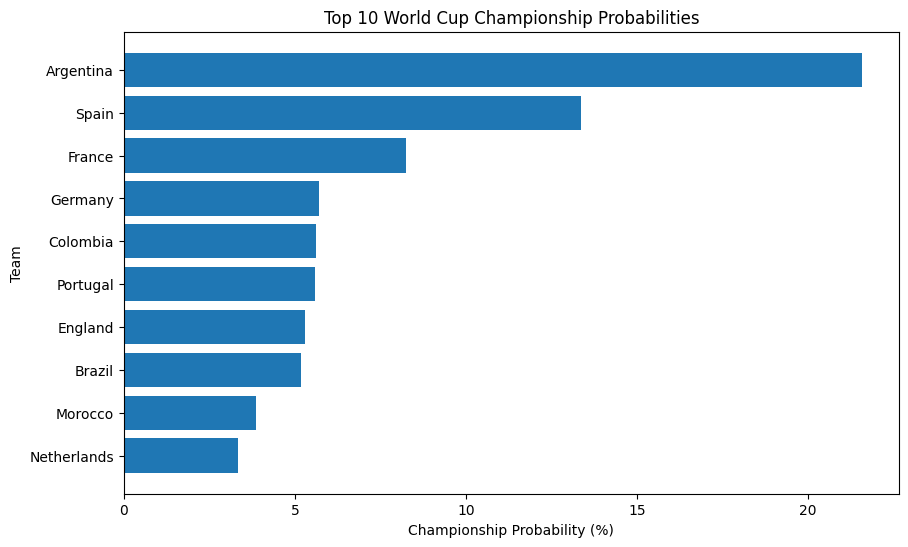

In [32]:
top_champions = monte_carlo_percentages.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_champions["team"], top_champions["champion"])
plt.xlabel("Championship Probability (%)")
plt.ylabel("Team")
plt.title("Top 10 World Cup Championship Probabilities")
plt.gca().invert_yaxis()
plt.show()

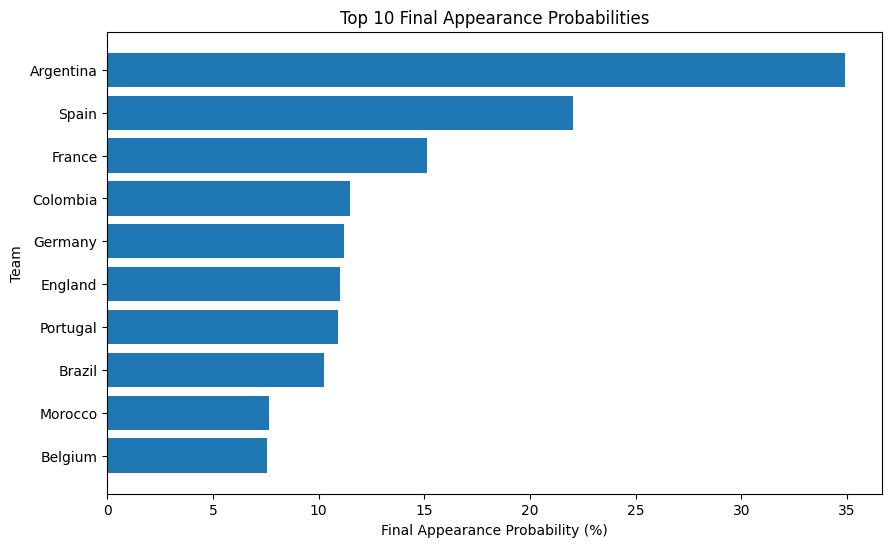

In [33]:
top_finalists = monte_carlo_percentages.sort_values(
    "final",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_finalists["team"], top_finalists["final"])
plt.xlabel("Final Appearance Probability (%)")
plt.ylabel("Team")
plt.title("Top 10 Final Appearance Probabilities")
plt.gca().invert_yaxis()
plt.show()

In [34]:
advancement_table = monte_carlo_percentages[
    [
        "team",
        "round_of_16",
        "quarterfinals",
        "semifinals",
        "final",
        "champion"
    ]
].copy()

advancement_table = advancement_table.sort_values(
    "champion",
    ascending=False
)

advancement_table

,team,round_of_16,quarterfinals,semifinals,final,champion
1,Argentina,94.07,74.74,53.45,34.91,21.58
28,Spain,75.50,45.80,34.98,22.03,13.36
15,France,76.46,43.14,27.07,15.14,8.25
16,Germany,68.39,36.81,21.93,11.18,5.69
9,Colombia,90.17,53.95,21.95,11.50,5.63
25,Portugal,63.95,30.68,19.82,10.92,5.60
14,England,75.71,41.43,22.60,11.03,5.29
6,Brazil,55.35,37.34,21.16,10.24,5.17
21,Morocco,49.17,32.26,15.19,7.67,3.86
22,Netherlands,50.83,32.62,15.46,7.45,3.33


## Saving Monte Carlo results

In [35]:
output_path = DATA_PROCESSED / "monte_carlo_knockout_simulation_results.csv"

monte_carlo_results.to_csv(output_path, index=False)

print("Saved Monte Carlo simulation results to:", output_path)

Saved Monte Carlo simulation results to: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed/monte_carlo_knockout_simulation_results.csv


## Final Notebook Conclusion

In this notebook, we moved the project from single-match prediction into full knockout-stage tournament simulation.

First, we loaded the saved Elo-enhanced model and rebuilt the feature pipeline needed to make predictions for new matchups. The model predicts normal match outcomes from Team A's perspective:

- Team A win
- Draw
- Team A loss

Because knockout matches require one team to advance, we converted draw probability into advancement probability using a simple beginner-friendly rule:

Team A advancement probability = Team A win probability + 0.5 × draw probability  
Team B advancement probability = Team B win probability + 0.5 × draw probability

Using this logic, we created functions for:

- predicting a normal match
- predicting a knockout match
- simulating one knockout round
- creating the next round's matchups
- simulating a full deterministic bracket
- running Monte Carlo tournament simulations

We then applied the simulator to the actual Round of 32 matchups. The deterministic bracket produced one fixed predicted path, while the Monte Carlo simulation produced a much richer result by estimating each team's probability of advancing through each stage.

Based on the Monte Carlo simulation, Argentina emerged as the strongest overall favorite, with an estimated championship probability of about **21.6%**. Spain was second at about **13.4%**, followed by France at **8.3%**. Germany, Colombia, Portugal, England, and Brazil were also among the strongest contenders, each landing in the roughly **5–6%** championship range.

The simulation also showed that some teams have strong early-round chances but lower championship probabilities. For example, the United States had about a **74.1%** chance to reach the Round of 16, but only about a **1.1%** chance to win the tournament. Similarly, Canada had about a **67.5%** chance to reach the Round of 16, but only about a **1.4%** championship probability. This shows why full-bracket simulation is more informative than looking at one match at a time.

This is a major project milestone because the pipeline now supports the full workflow:

Historical data  
→ feature engineering  
→ Elo-enhanced model training  
→ saved prediction model  
→ single-match knockout prediction  
→ deterministic bracket simulation  
→ Monte Carlo tournament probabilities

However, this version is still a simplified first simulator. It does not yet account for actual 2026 group-stage form, player availability, injuries, penalty shootout skill, tactical matchups, or probability calibration. The current draw-to-advancement rule also assumes that both teams are equally likely to advance if the model predicts a draw, which is a reasonable beginner assumption but not a final solution.

The next major improvements would be to calibrate the model probabilities, improve the draw-to-advancement logic using Elo or team strength, add more features such as FIFA rankings and home/neutral-site effects, and eventually update the inputs with real 2026 World Cup group-stage results before making final knockout predictions.